In [1]:
%load_ext autoreload
%autoreload 2
%cd /home/xux/Desktop/AlphaVariant/Benchmark

/home/xux/Desktop/AlphaVariant/Benchmark


# Performance figures — median max fitness & top-128 mean fitness

Horizontal dot plots (dot = median, whiskers = Q1–Q3 IQR) for:
- **4-site benchmark**: GB1, PhoQ, TrpB
- **Multi-site oracle benchmark**: AAV, CreiLOV, PAB1

Palette: AlphaVariant = vermilion; ALDE/EVOLVEpro/MULTIevolve = dark gray; all other baselines = light/medium gray.
Methods follow a fixed order (by mean rank across the group's datasets, best at top) consistent across every panel.

Outputs (PNG + PDF + SVG) are written to `figures/` and `figures/ms_oracles/`.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, '.')
from utils.plot_style_utils import (
    PRIMARY_COMPARISON, VERMILION, method_color,
    apply_nature_rcparams, save_figure,
)

FIGURES_DIR = 'figures'

apply_nature_rcparams({
    'axes.labelsize': 8.2,
    'xtick.labelsize': 6.8,
})

DISPLAY_NAMES = {'FLEXS': 'AdaLead'}

def display_name(method):
    return DISPLAY_NAMES.get(method, method)

print('Setup complete.')

## Task configuration

Edit `ACTIVE_TASK` to switch between `'4site'` and `'multisite'`, or run both cells below.

In [3]:
TASKS = {
    '4site': {
        'csv': os.path.join(FIGURES_DIR, 'alphavariant_comparison_median_iqr.csv'),
        'outdir': FIGURES_DIR,
        'dataset_order': ['4site_GB1', '4site_PhoQ', '4site_TRPB'],
        'dataset_labels': {
            '4site_GB1': 'GB1 4-site',
            '4site_PhoQ': 'PhoQ 4-site',
            '4site_TRPB': 'TrpB 4-site',
        },
        'main_methods': {
            'Random', 'GreedyWalk', 'ALDE', 'FLEXS', 'AiCE',
            'ftMLDE', 'CLADE', 'AlphaVariant', 'MULTIevolve', 'EVOLVEpro',
        },
        'highlight': {'AlphaVariant'},
        'max_prefix': 'main_figure_max_fitness_median_iqr',
        'top_prefix': 'supplementary_figure_top128_mean_fitness_median_iqr',
        'max_xlim': (0.0, 1.1), 'max_xticks': np.arange(0.0, 1.01, 0.2),
        'top_xlim': (0.0, 0.82), 'top_xticks': np.arange(0.0, 0.71, 0.1),
    },
    'multisite': {
        'csv': os.path.join(FIGURES_DIR, 'ms_oracles', 'multisite_oracle_median_iqr.csv'),
        'outdir': os.path.join(FIGURES_DIR, 'ms_oracles'),
        'dataset_order': ['ms_AAV', 'ms_CreiLOV', 'ms_PAB1'],
        'dataset_labels': {
            'ms_AAV': 'AAV multi-site',
            'ms_CreiLOV': 'CreiLOV multi-site',
            'ms_PAB1': 'PAB1 multi-site',
        },
        'main_methods': {
            'Random', 'GreedyWalk', 'ALDE', 'CLADE', 'ftMLDE',
            'AdaLead', 'MULTIevolve', 'EVOLVEpro', 'AiCE', 'AlphaVariant',
        },
        'highlight': {'AlphaVariant'},
        'max_prefix': 'main_figure_multisite_max_fitness_median_iqr',
        'top_prefix': 'supplementary_figure_multisite_top128_mean_fitness_median_iqr',
        'max_xlim': (0.0, 1.1), 'max_xticks': np.arange(0.0, 1.01, 0.2),
        'top_xlim': (0.0, 1.05), 'top_xticks': np.arange(0.0, 1.01, 0.2),
    },
}

print('Task configs loaded.')

Task configs loaded.


## Plotting helpers

In [ ]:
def global_method_order(df, cfg, metric_med):
    """Fixed method order for the group (best → worst by mean rank across datasets)."""
    datasets = cfg['dataset_order']
    main_methods = cfg['main_methods']
    sub = df[(df['dataset'].isin(datasets)) & (df['method'].isin(main_methods))].copy()
    sub['rank'] = sub.groupby('dataset')[metric_med].rank(ascending=False, method='average')
    mean_rank = sub.groupby('method')['rank'].mean().sort_values()
    return mean_rank.index.tolist()


def style_axis(ax, xlim, xticks):
    ax.set_xlim(*xlim)
    ax.set_xticks(xticks)
    ax.xaxis.grid(True, color='#E6E6E6', linewidth=0.55, zorder=0)
    ax.yaxis.grid(False)
    ax.tick_params(axis='both', length=2.4, width=0.55, color='#333333', pad=2)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#333333')
        ax.spines[spine].set_linewidth(0.6)


def plot_metric_figure(df, cfg, metric_med, metric_q1, metric_q3,
                       xlabel, title, output_prefix, xlim, xticks, seed_note,
                       save=True):
    dataset_order = cfg['dataset_order']
    dataset_labels = cfg['dataset_labels']
    main_methods = cfg['main_methods']
    highlight = cfg['highlight']
    outdir = cfg['outdir']

    order_best_first = global_method_order(df, cfg, metric_med)
    methods_btt = order_best_first[::-1]   # bottom-to-top: best sits at top
    y = np.arange(len(methods_btt))

    n_panels = len(dataset_order)
    fig, axes = plt.subplots(1, n_panels, figsize=(2.15 * n_panels + 1.35, 3.35),
                             sharey=True)
    axes = np.atleast_1d(axes)
    fig.patch.set_facecolor('white')

    for col, (ax, dataset) in enumerate(zip(axes, dataset_order)):
        sub = df[(df['dataset'] == dataset) & (df['method'].isin(main_methods))]
        sub = sub.set_index('method')
        med = np.array([sub.loc[m, metric_med] if m in sub.index else np.nan
                        for m in methods_btt], dtype=float)
        q1  = np.array([sub.loc[m, metric_q1]  if m in sub.index else np.nan
                        for m in methods_btt], dtype=float)
        q3  = np.array([sub.loc[m, metric_q3]  if m in sub.index else np.nan
                        for m in methods_btt], dtype=float)
        err_lo = np.clip(med - q1, 0.0, None)
        err_hi = np.clip(q3 - med, 0.0, None)

        pt_colors = [method_color(m) for m in methods_btt]
        pt_sizes  = [40 if m in highlight else 26 for m in methods_btt]
        pt_edges  = ['#111111' if m in highlight else 'white' for m in methods_btt]
        pt_edge_w = [0.9 if m in highlight else 0.45 for m in methods_btt]

        ax.errorbar(med, y, xerr=np.vstack([err_lo, err_hi]), fmt='none',
                    ecolor='#5A5A5A', elinewidth=0.7, capsize=2.0,
                    capthick=0.6, zorder=3)
        ax.scatter(med, y, s=pt_sizes, c=pt_colors, edgecolors=pt_edges,
                   linewidths=pt_edge_w, zorder=4, clip_on=False)

        ax.set_title(dataset_labels[dataset], pad=6, fontweight='bold')
        ax.set_ylim(-0.6, len(methods_btt) - 0.4)
        ax.set_yticks(y)
        style_axis(ax, xlim, xticks)
        ax.set_xlabel(xlabel, labelpad=3)
        if col == 0:
            ax.set_yticklabels([display_name(m) for m in methods_btt])
            for tick in ax.get_yticklabels():
                if tick.get_text() in {display_name(m) for m in highlight}:
                    tick.set_fontweight('bold')
                    tick.set_color(mcolors.to_hex(VERMILION))
        else:
            ax.tick_params(axis='y', length=0)

    fig.suptitle(title, x=0.052, y=0.985, ha='left', va='top',
                 fontsize=10.0, fontweight='bold')
    fig.text(
        0.052, 0.015,
        f'Dots indicate the median across {seed_note} independent seeds; '
        'whiskers indicate Q1–Q3 (interquartile range). Methods share a fixed '
        'order (mean rank across this group\'s datasets, best at top) in every '
        'panel. Pairwise comparisons: Bonferroni-corrected Wilcoxon signed-rank test.',
        ha='left', va='bottom', fontsize=5.6, color='#4D4D4D',
    )
    fig.subplots_adjust(left=0.135, right=0.985, bottom=0.20, top=0.86, wspace=0.18)

    if save:
        save_figure(fig, outdir, output_prefix)

    plt.show()
    return fig


print('Helpers defined.')

## 4-site benchmark — maximum fitness

  Saved: figures/main_figure_max_fitness_median_iqr.png
  Saved: figures/main_figure_max_fitness_median_iqr.pdf
  Saved: figures/main_figure_max_fitness_median_iqr.svg


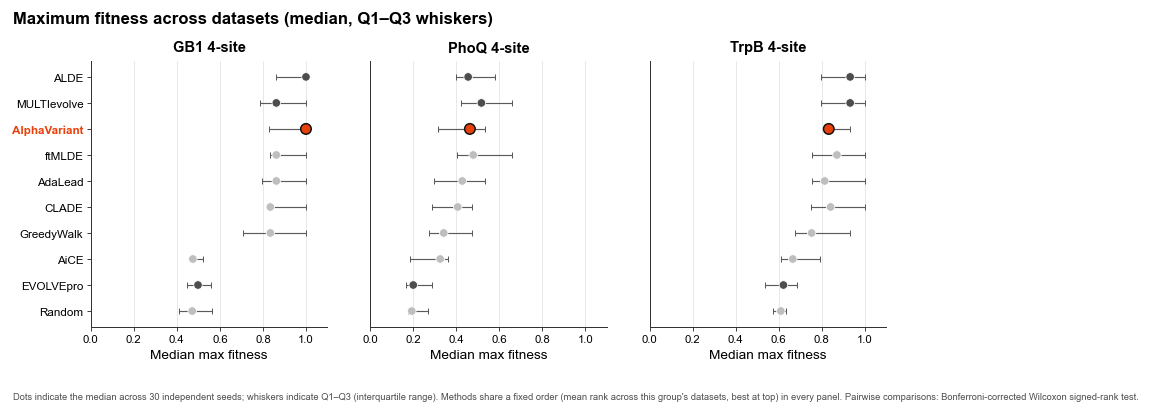

In [5]:
cfg = TASKS['4site']
df = pd.read_csv(cfg['csv'])
seed_note = int(df['n'].max()) if 'n' in df.columns else 30

fig = plot_metric_figure(
    df, cfg,
    metric_med='max_fitness_median', metric_q1='max_fitness_q1', metric_q3='max_fitness_q3',
    xlabel='Median max fitness',
    title='Maximum fitness across datasets (median, Q1–Q3 whiskers)',
    output_prefix=cfg['max_prefix'],
    xlim=cfg['max_xlim'], xticks=cfg['max_xticks'],
    seed_note=seed_note,
)

## 4-site benchmark — top-128 mean fitness (supplementary)

  Saved: figures/supplementary_figure_top128_mean_fitness_median_iqr.png
  Saved: figures/supplementary_figure_top128_mean_fitness_median_iqr.pdf
  Saved: figures/supplementary_figure_top128_mean_fitness_median_iqr.svg


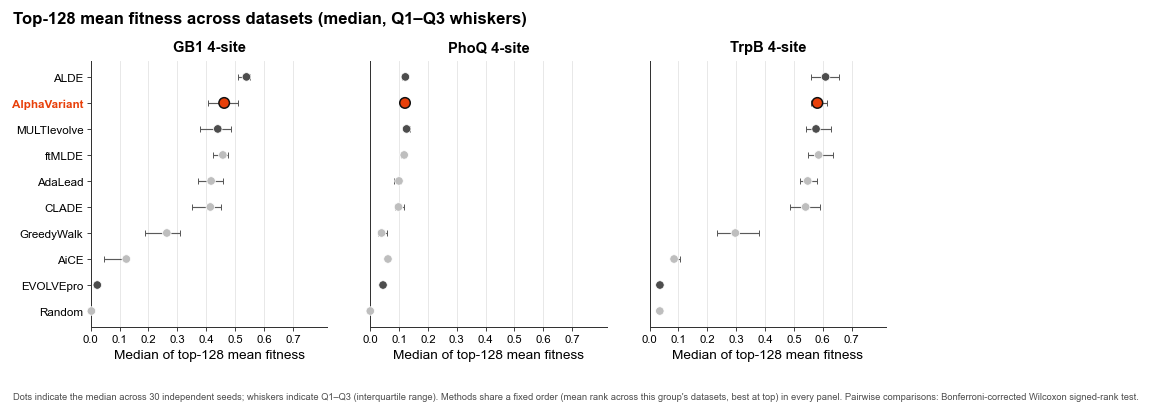

In [6]:
fig = plot_metric_figure(
    df, cfg,
    metric_med='top128_median', metric_q1='top128_q1', metric_q3='top128_q3',
    xlabel='Median of top-128 mean fitness',
    title='Top-128 mean fitness across datasets (median, Q1–Q3 whiskers)',
    output_prefix=cfg['top_prefix'],
    xlim=cfg['top_xlim'], xticks=cfg['top_xticks'],
    seed_note=seed_note,
)

## Multi-site oracle benchmark — maximum fitness

  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_median_iqr.png
  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_median_iqr.pdf
  Saved: figures/ms_oracles/main_figure_multisite_max_fitness_median_iqr.svg


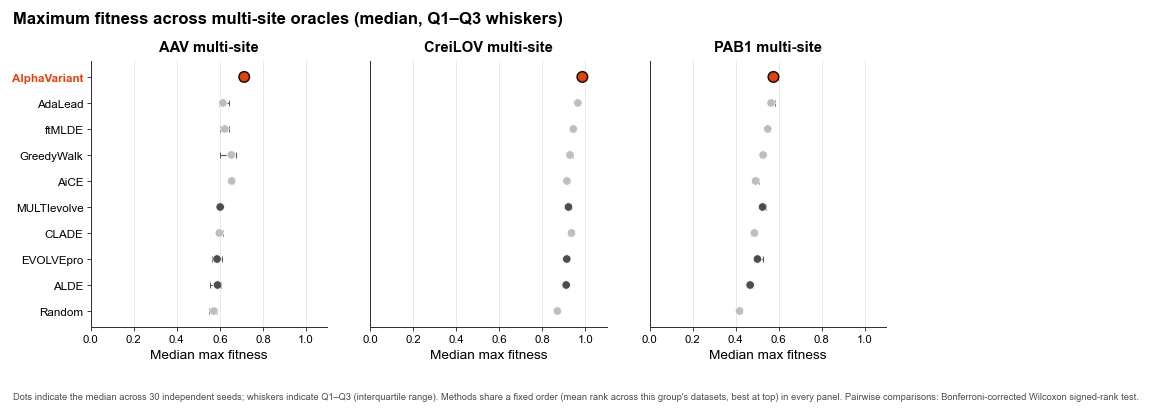

In [7]:
cfg_ms = TASKS['multisite']
df_ms = pd.read_csv(cfg_ms['csv'])
seed_note_ms = int(df_ms['n'].max()) if 'n' in df_ms.columns else 30

fig = plot_metric_figure(
    df_ms, cfg_ms,
    metric_med='max_fitness_median', metric_q1='max_fitness_q1', metric_q3='max_fitness_q3',
    xlabel='Median max fitness',
    title='Maximum fitness across multi-site oracles (median, Q1–Q3 whiskers)',
    output_prefix=cfg_ms['max_prefix'],
    xlim=cfg_ms['max_xlim'], xticks=cfg_ms['max_xticks'],
    seed_note=seed_note_ms,
)

## Multi-site oracle benchmark — top-128 mean fitness (supplementary)

  Saved: figures/ms_oracles/supplementary_figure_multisite_top128_mean_fitness_median_iqr.png
  Saved: figures/ms_oracles/supplementary_figure_multisite_top128_mean_fitness_median_iqr.pdf
  Saved: figures/ms_oracles/supplementary_figure_multisite_top128_mean_fitness_median_iqr.svg


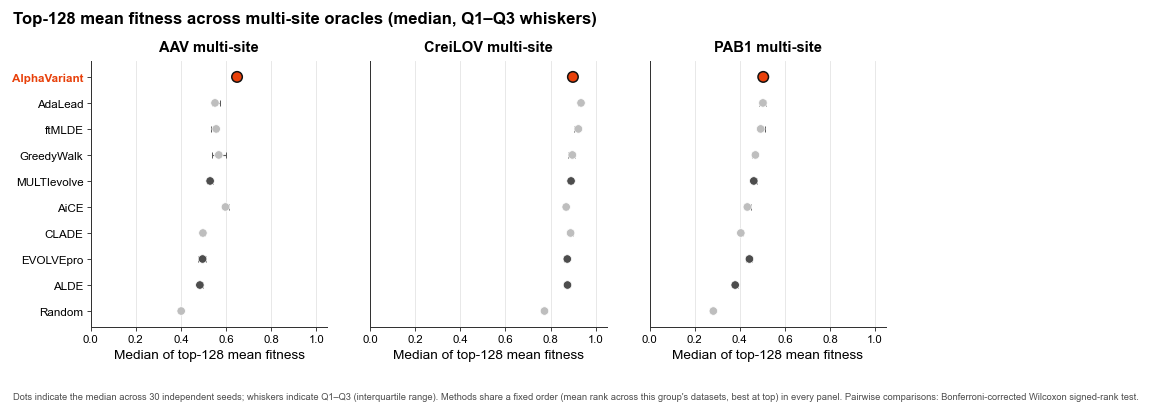

In [8]:
fig = plot_metric_figure(
    df_ms, cfg_ms,
    metric_med='top128_median', metric_q1='top128_q1', metric_q3='top128_q3',
    xlabel='Median of top-128 mean fitness',
    title='Top-128 mean fitness across multi-site oracles (median, Q1–Q3 whiskers)',
    output_prefix=cfg_ms['top_prefix'],
    xlim=cfg_ms['top_xlim'], xticks=cfg_ms['top_xticks'],
    seed_note=seed_note_ms,
)